In [21]:
import numpy as np
from matplotlib import pyplot as plt
from analysis import *
from ast import literal_eval
np.set_printoptions(precision=3, suppress=True)



### IMU data

In [25]:
data = open(r"data\pitch_readings.txt").read()


In [ ]:
sectors = data.split("NEW_MEASUREMENTS\n")[1:]

sector_data = []
for sector in sectors:
    lines = sector.splitlines()
    tmp = []
    for line in lines:
        tmp.append(literal_eval(line))
    tmp = np.array(tmp)
    sector_data.append(tmp)

### Plot and Analyze

In [28]:

def ellipse3d_from_mag(mag, scale=2, n_points=120):
    centroid = mag.mean(axis=0)
    U, S, Vt = np.linalg.svd(mag - centroid)
    basis = Vt[:2]

    coords2d = (mag - centroid) @ basis.T
    cov = np.cov(coords2d.T)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.linspace(0, 2 * np.pi, n_points)
    radii = np.sqrt(vals) * scale
    ellipse2d = np.vstack((radii[0] * np.cos(theta), radii[1] * np.sin(theta)))

    return centroid[:, None] + basis.T @ (vecs @ ellipse2d)

def plot_mag_ellipse(ax, mag, **kwargs):
    ellipse3d = ellipse3d_from_mag(mag, **kwargs)
    ax.plot(ellipse3d[0], ellipse3d[1], ellipse3d[2],
            color='k', linewidth=1, alpha=0.8)


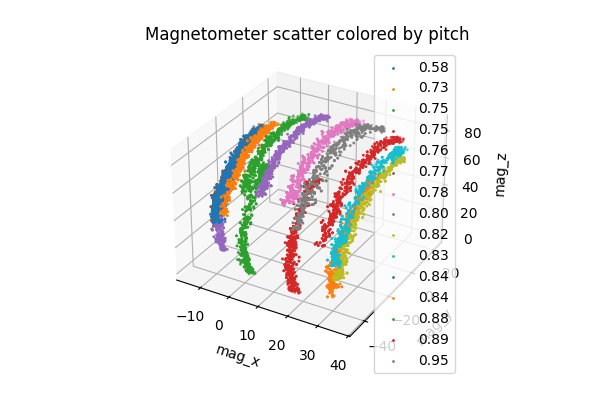

In [45]:
%matplotlib widget
plt.clf()
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

pitches = []
for sector in sector_data:
    mag = sector[:, :3]
    accx,accy,accz = sector[:, 3:6].T
    pitch = np.arctan2(np.sqrt(accx*accx+accy*accy), accz)
    pitches.append(np.median(pitch))
sector_data = np.array(sector_data)[np.argsort(pitches)]

for sector in sector_data:
    mag = sector[:, :3]
    accx,accy,accz = sector[:, 3:6].T
    pitch = np.arctan2(np.sqrt(accx*accx+accy*accy), accz)
    ax.scatter(*mag.T, s=1, label=f"{np.median(pitch):.02f}")
    


ax.set_xlabel('mag_x')
ax.set_ylabel('mag_y')
ax.set_zlabel('mag_z')
ax.set_title('Magnetometer scatter colored by pitch')
plt.legend()
plt.show()

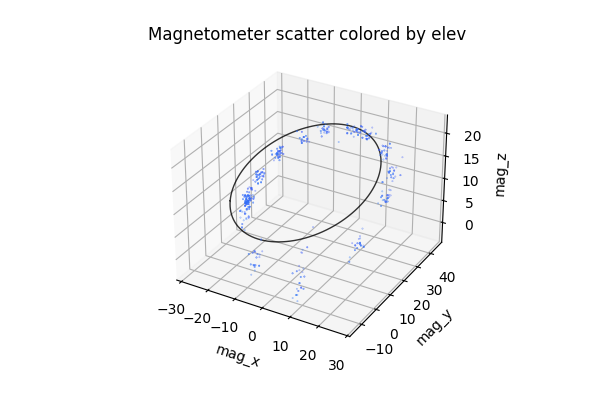

In [54]:
%matplotlib widget
plt.clf()
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.get_cmap('rainbow')
all_data = np.vstack(sector_data)

mag_all = all_data[:, :3]
mag_all -= np.mean(mag_all, axis=0)
accx,accy,accz = acc_all = all_data[:, 3:6].T
elev_all = np.arctan2(np.sqrt(accx*accx+accy*accy), accz)

n_bins = 25
bin_edges = np.linspace(elev_all.min(), elev_all.max(), n_bins + 1)
bin_ids = np.digitize(elev_all, bin_edges, right=True) - 1
bin_ids = np.clip(bin_ids, 0, n_bins - 1)

norm = plt.Normalize(vmin=elev_all.min(), vmax=elev_all.max())

for i in range(n_bins):
    mask = bin_ids == i
    if mask.sum() < 10:
        continue

    if i != 3: continue

    mag_bin = mag_all[mask]
    elev_bin = elev_all[mask]

    ax.scatter(*mag_bin.T, c=elev_bin, cmap=cmap, norm=norm, s=.1, alpha=0.6)

    plot_mag_ellipse(ax, mag_bin, scale=1.4, n_points=120)

ax.set_xlabel('mag_x')
ax.set_ylabel('mag_y')
ax.set_zlabel('mag_z')
ax.set_title('Magnetometer scatter colored by elev')
plt.show()